<a href="https://colab.research.google.com/github/s-serov/---/blob/main/%D0%9B%D0%90%D0%912_2_%D0%A1%D1%94%D1%80%D0%BE%D0%B2_3_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Завантаження даних та імпорт бібліотек

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# 1. Завантаження датасету Titanic
path_titanic = kagglehub.dataset_download("mahmoudshogaa/titanic-dataset")
file_titanic = [f for f in os.listdir(path_titanic) if f.endswith('.csv')][0]
df_titanic = pd.read_csv(os.path.join(path_titanic, file_titanic))
print(f"Titanic завантажено успішно. Розмірність: {df_titanic.shape}")

# 2. Завантаження датасету Amazon Bestsellers
path_amazon = kagglehub.dataset_download("sootersaalu/amazon-top-50-bestselling-books-2009-2019")
file_amazon = [f for f in os.listdir(path_amazon) if f.endswith('.csv')][0]
df_amazon = pd.read_csv(os.path.join(path_amazon, file_amazon))
print(f"Amazon завантажено успішно. Розмірність: {df_amazon.shape}")

sns.set_theme(style="whitegrid")

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Titanic завантажено успішно. Розмірність: (891, 12)
Using Colab cache for faster access to the 'amazon-top-50-bestselling-books-2009-2019' dataset.
Amazon завантажено успішно. Розмірність: (550, 7)


Дослідження структури та обробка пропусків

In [4]:
# Огляд перших рядків та структури
display(df_titanic.head())
df_titanic.info()

# Перевірка на пропущені значення
print("\nПропущені значення:")
print(df_titanic.isnull().sum())

# Заповнюємо медіаною пропуски у віці
if 'Age' in df_titanic.columns:
    df_titanic['Age'] = df_titanic['Age'].fillna(df_titanic['Age'].median())

# Описова статистика числових стовпців
display(df_titanic.describe())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Пропущені значення:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked      

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Візуалізація закономірностей Titanic

/tmp/ipykernel_2614/2390933207.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_titanic, x='Survived', ax=axes[0], palette='Set2')
/tmp/ipykernel_2614/2390933207.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Загинули', 'Вижили'])
/tmp/ipykernel_2614/2390933207.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_titanic, x='Sex', y='Survived', ax=axes[1], palette='pastel', ci=None)
/tmp/ipykernel_2614/2390933207.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_titanic, x='Sex', y='Surv

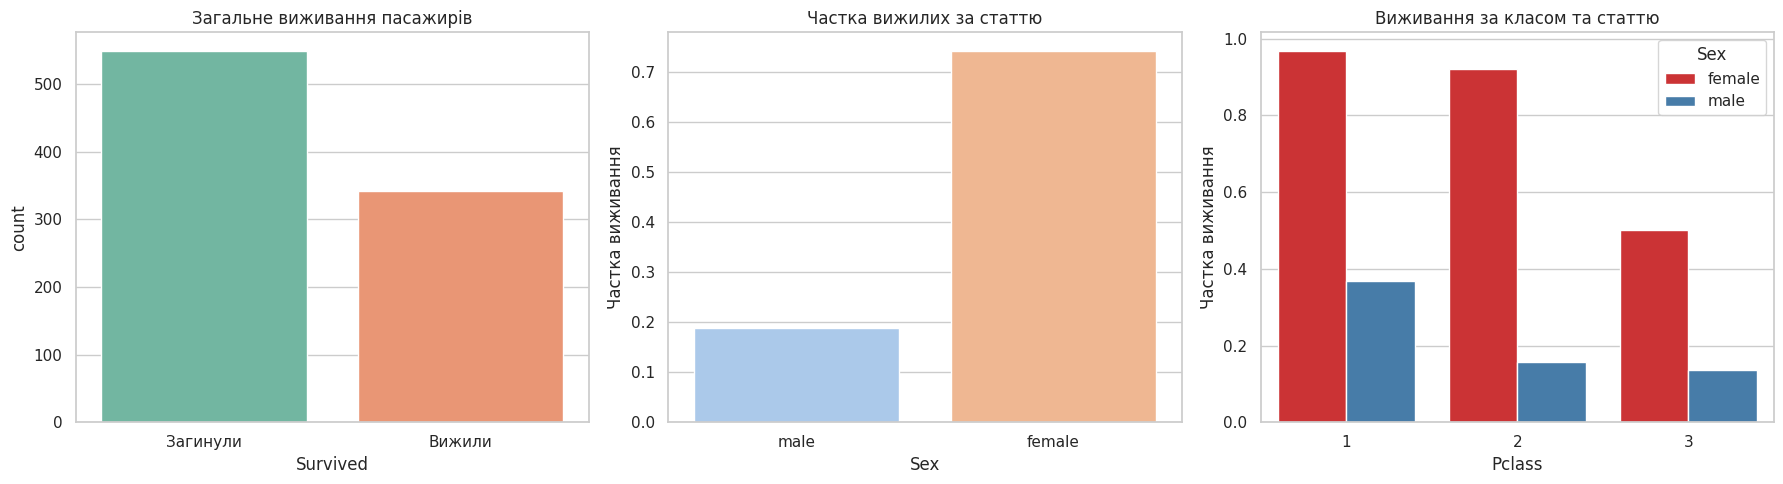

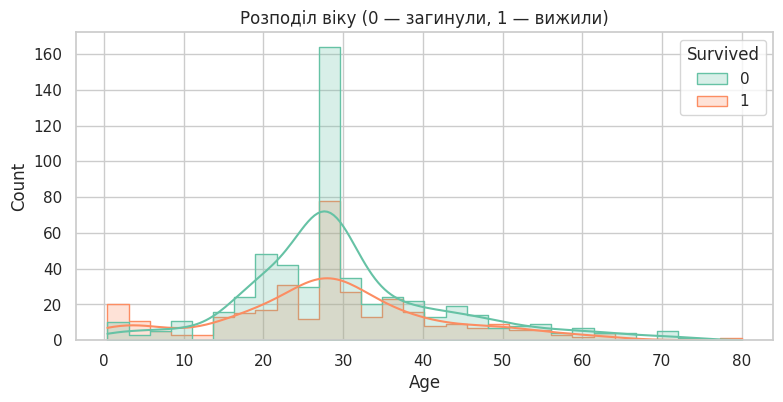

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Загальне співвідношення вижилих (Survived: 0 = загинув, 1 = вижив)
sns.countplot(data=df_titanic, x='Survived', ax=axes[0], palette='Set2')
axes[0].set_title('Загальне виживання пасажирів')
axes[0].set_xticklabels(['Загинули', 'Вижили'])

# 2. Рівень виживання за статтю
sns.barplot(data=df_titanic, x='Sex', y='Survived', ax=axes[1], palette='pastel', ci=None)
axes[1].set_title('Частка вижилих за статтю')
axes[1].set_ylabel('Частка виживання')

# 3. Виживання залежно від класу квитка (Pclass)
sns.barplot(data=df_titanic, x='Pclass', y='Survived', hue='Sex', ax=axes[2], palette='Set1', ci=None)
axes[2].set_title('Виживання за класом та статтю')
axes[2].set_ylabel('Частка виживання')

plt.tight_layout()
plt.show()

# Розподіл віку за статусом виживання
plt.figure(figsize=(9, 4))
sns.histplot(data=df_titanic, x='Age', hue='Survived', kde=True, bins=30, palette='Set2', element='step')
plt.title('Розподіл віку (0 — загинули, 1 — вижили)')
plt.show()

Первинний огляд та перевірка дублікатів

In [6]:
# Огляд структури
display(df_amazon.head())
df_amazon.info()

# Перевірка наявності пропусків
print("\nПропуски в датасеті Amazon:")
print(df_amazon.isnull().sum())

# Зведення за жанрами
genre_summary = df_amazon.groupby('Genre').agg(
    Кількість_записів=('Name', 'count'),
    Середній_рейтинг=('User Rating', 'mean'),
    Середня_ціна=('Price', 'mean'),
    Медіанна_ціна=('Price', 'median'),
    Середня_кількість_відгуків=('Reviews', 'mean')
).reset_index()

display(genre_summary)

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         550 non-null    object 
 1   Author       550 non-null    object 
 2   User Rating  550 non-null    float64
 3   Reviews      550 non-null    int64  
 4   Price        550 non-null    int64  
 5   Year         550 non-null    int64  
 6   Genre        550 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 30.2+ KB

Пропуски в датасеті Amazon:
Name           0
Author         0
User Rating    0
Reviews        0
Price          0
Year           0
Genre          0
dtype: int64


,Genre,Кількість_записів,Середній_рейтинг,Середня_ціна,Медіанна_ціна,Середня_кількість_відгуків
0,Fiction,240,4.648333,10.850000,9.0,15683.791667
1,Non Fiction,310,4.595161,14.841935,12.0,9065.145161


Візуалізація ринку бестселерів

/tmp/ipykernel_2614/59058691.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_amazon, x='Genre', ax=axes[0], palette='Blues')
/tmp/ipykernel_2614/59058691.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_amazon, x='Genre', y='Price', ax=axes[2], palette='Pastel1')


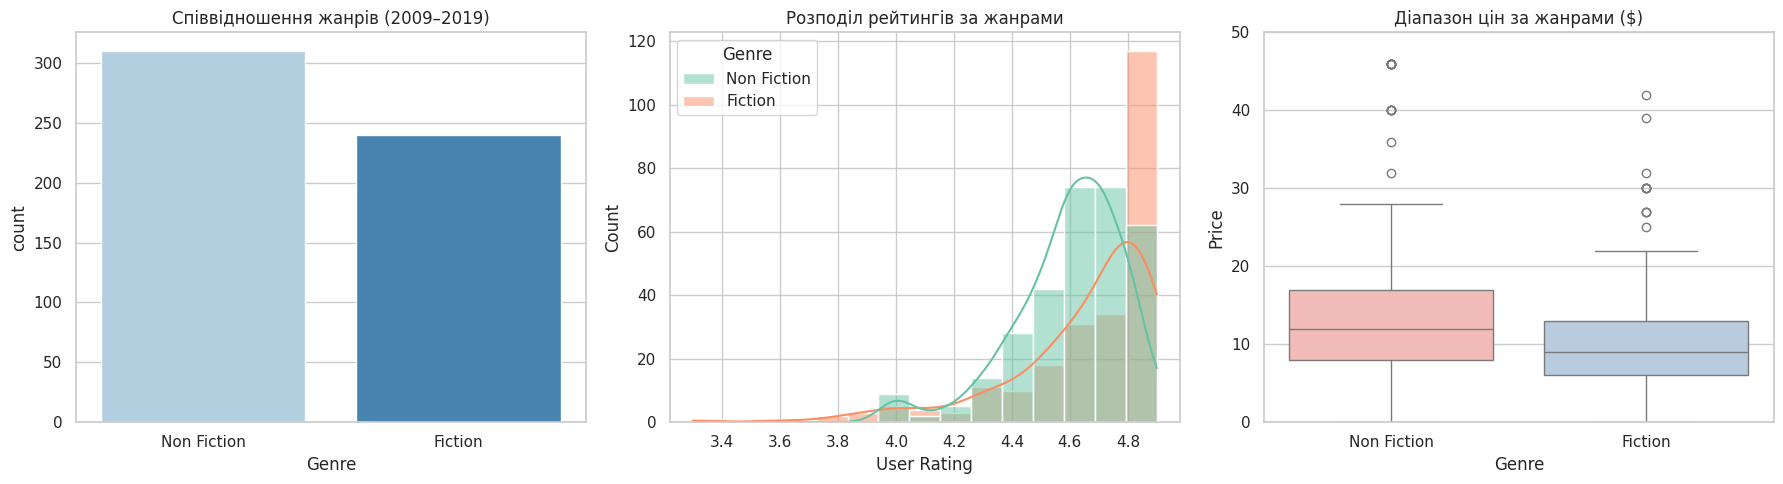

/tmp/ipykernel_2614/59058691.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_authors.values, y=top_authors.index, palette='crest')


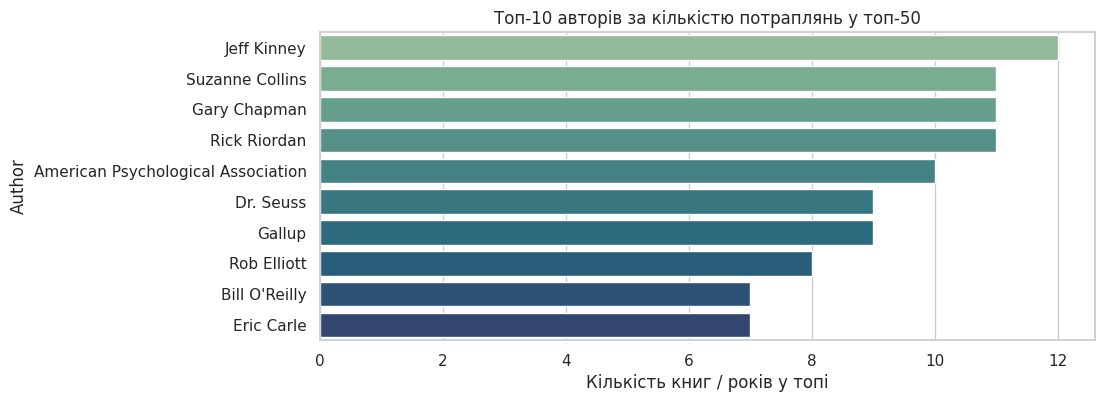

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Розподіл жанрів (Fiction vs Non Fiction)
sns.countplot(data=df_amazon, x='Genre', ax=axes[0], palette='Blues')
axes[0].set_title('Співвідношення жанрів (2009–2019)')

# 2. Розподіл оцінок користувачів
sns.histplot(data=df_amazon, x='User Rating', hue='Genre', bins=15, kde=True, ax=axes[1], palette='Set2')
axes[1].set_title('Розподіл рейтингів за жанрами')

# 3. Розподіл цін (Boxplot для оцінки викидів)
sns.boxplot(data=df_amazon, x='Genre', y='Price', ax=axes[2], palette='Pastel1')
axes[2].set_title('Діапазон цін за жанрами ($)')
axes[2].set_ylim(0, 50)  # обмежимо до 50$, щоб згладити поодинокі екстремальні викиди

plt.tight_layout()
plt.show()

# Топ-10 авторів із найбільшою кількістю появ у топі
plt.figure(figsize=(10, 4))
top_authors = df_amazon['Author'].value_counts().head(10)
sns.barplot(x=top_authors.values, y=top_authors.index, palette='crest')
plt.title('Топ-10 авторів за кількістю потраплянь у топ-50')
plt.xlabel('Кількість книг / років у топі')
plt.show()

Висновки

Titanic: жінки мали суттєво вищий відсоток виживання (74%),ніж чоловіки  (~19%). Пасажири 1-го класу мали найбільшу частку врятованих, тоді як серед 3-го класу більшість загинула. Пріоритет під час евакуації мали діти, що помітно за піком виживання у віковій групі до 10 років.

Amazon Bestsellers: література жанру Non-Fiction переважає за кількістю входжень у топ-50 порівняно з Fiction. Оцінки читачів сильно зміщені вправо: більшість бестселерів мають рейтинг від 4.5 до 4.9. Більшість бестселерів зосереджені в доступному діапазоні ($8–$15), проте нон-фікшн видання демонструють дещо ширший розкид цін.